# Imports

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps

# map def

In [357]:
def reg_map(ds_to_plt, comparison, bounds=[20, -180, 30, -30], name='figure',
           color=cmaps.posneg_1, lcolor=['magenta', 'cyan'],
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    ccomp, ccomp_lon = cutil.add_cyclic_point(comparison, comparison.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2]+1, 15)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    re_contour = ax.contourf(ccomp_lon, comparison.lat, ccomp,
                             levels=lev,
                             # levels=40,
                             transform=ccrs.PlateCarree(), cmap=color,
                             extend='both')
    
    mod_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              transform=ccrs.PlateCarree(),
                              linestyles='-',
                              hatches=['...'],
                              levels=[-0.1, 0, 0.1],
                              colors=lcolor,
                              alpha=0.1,
                              extend='both')

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(re_contour, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

# Data select

In [312]:
JJASST_CANI_r = xr.open_dataset('CESM/JJA_CANI_SST_reg.nc')
JJASST_EANI_r = xr.open_dataset('CESM/JJA_EANI_SST_reg.nc')
SONSST_CANI_r = xr.open_dataset('CESM/SON_CANI_SST_reg.nc')
SONSST_EANI_r = xr.open_dataset('CESM/SON_EANI_SST_reg.nc')

JJAPRECT_CANI_r = xr.open_dataset('CESM/JJA_CANI_PRECT_reg.nc')
JJAPRECT_EANI_r = xr.open_dataset('CESM/JJA_EANI_PRECT_reg.nc')
SONPRECT_CANI_r = xr.open_dataset('CESM/SON_CANI_PRECT_reg.nc')
SONPRECT_EANI_r = xr.open_dataset('CESM/SON_EANI_PRECT_reg.nc')
# reanalysisC/EANI_SEASONvar_regression
rCANI_JJAprecip_r = xr.open_dataset('Reanalysis/CANI_precip_JJA.nc')
rCANI_SONprecip_r = xr.open_dataset('Reanalysis/CANI_precip_SON.nc')
rEANI_JJAprecip_r = xr.open_dataset('Reanalysis/EANI_precip_JJA.nc')
rEANI_SONprecip_r = xr.open_dataset('Reanalysis/EANI_precip_SON.nc')

rCANI_JJA_SST_r = xr.open_dataset('Reanalysis/1914_2014sst/CANI_SST_JJA.nc')
rCANI_SON_SST_r = xr.open_dataset('Reanalysis/1914_2014sst/CANI_SST_SON.nc')
rEANI_JJA_SST_r = xr.open_dataset('Reanalysis/1914_2014sst/EANI_SST_JJA.nc')
rEANI_SON_SST_r = xr.open_dataset('Reanalysis/1914_2014sst/EANI_SST_SON.nc')

In [313]:
new_dims = {'longitude': 'lon', 'latitude': 'lat'}

rCANI_JJA_SST_r = rCANI_JJA_SST_r.rename(new_dims)
rCANI_SON_SST_r = rCANI_SON_SST_r.rename(new_dims)
rEANI_JJA_SST_r = rEANI_JJA_SST_r.rename(new_dims)
rEANI_SON_SST_r = rEANI_SON_SST_r.rename(new_dims)

In [314]:
rCANI_JJA_SST_r = rCANI_JJA_SST_r.sortby(rCANI_JJA_SST_r.lat)
rCANI_SON_SST_r = rCANI_SON_SST_r.sortby(rCANI_SON_SST_r.lat)
rEANI_JJA_SST_r = rEANI_JJA_SST_r.sortby(rCANI_JJA_SST_r.lat)
rEANI_SON_SST_r = rEANI_SON_SST_r.sortby(rEANI_SON_SST_r.lat)

In [315]:
rCANI_JJA_SST_r

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 180, lon: 360)
Coordinates:
  * lat        (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon        (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    cov        (lat, lon) float32 259kB ...
    cor        (lat, lon) float32 259kB ...
    r2         (lat, lon) float32 259kB ...
    slope      (lat, lon) float32 259kB ...
    intercept  (lat, lon) float32 259kB ...
    pvalue     (lat, lon) float32 259kB ...
    stderr     (lat, lon) float32 259kB ...
    n          (lat, lon) int16 130kB ...

# Select only significant values

In [325]:
rCANI_JJAprecip_slope_sig = rCANI_JJAprecip_r['slope'].where(rCANI_JJAprecip_r['pvalue'] <= 0.05)
rCANI_SONprecip_slope_sig = rCANI_SONprecip_r['slope'].where(rCANI_SONprecip_r['pvalue'] <= 0.05)
rEANI_JJAprecip_slope_sig = rEANI_JJAprecip_r['slope'].where(rEANI_JJAprecip_r['pvalue'] <= 0.05)
rEANI_SONprecip_slope_sig = rEANI_SONprecip_r['slope'].where(rEANI_SONprecip_r['pvalue'] <= 0.05)

rCANI_JJA_SST_slope_sig = rCANI_JJA_SST_r['slope'].where(rCANI_JJA_SST_r['pvalue'] <= 0.05)
rCANI_SON_SST_slope_sig = rCANI_SON_SST_r['slope'].where(rCANI_SON_SST_r['pvalue'] <= 0.05)
rEANI_JJA_SST_slope_sig = rEANI_JJA_SST_r['slope'].where(rEANI_JJA_SST_r['pvalue'] <= 0.05)
rEANI_SON_SST_slope_sig = rEANI_SON_SST_r['slope'].where(rEANI_SON_SST_r['pvalue'] <= 0.05)

# Ensemble means

In [317]:
ens_jja_sstvEANI = JJASST_EANI_r.mean(dim='member')
ens_jja_sstvCANI = JJASST_CANI_r.mean(dim='member')
ens_son_sstvEANI = SONSST_EANI_r.mean(dim='member')
ens_son_sstvCANI = SONSST_CANI_r.mean(dim='member')

ens_jja_PRECTvCANI = JJAPRECT_CANI_r.mean(dim='member')
ens_jja_PRECTvEANI = JJAPRECT_EANI_r.mean(dim='member')
ens_son_PRECTvCANI = SONPRECT_CANI_r.mean(dim='member')
ens_son_PRECTvEANI = SONPRECT_EANI_r.mean(dim='member')

In [318]:
ens_jja_sstvEANI_sig_slope = ens_jja_sstvEANI['slope'].where(ens_jja_sstvEANI['pvalue'] <= 0.05)
ens_jja_sstvCANI_sig_slope = ens_jja_sstvCANI['slope'].where(ens_jja_sstvCANI['pvalue'] <= 0.05)
ens_son_sstvEANI_sig_slope = ens_son_sstvEANI['slope'].where(ens_son_sstvEANI['pvalue'] <= 0.05)
ens_son_sstvCANI_sig_slope = ens_son_sstvCANI['slope'].where(ens_son_sstvCANI['pvalue'] <= 0.05)

In [319]:
ens_jja_PRECTvCANI_sig_slope = ens_jja_PRECTvCANI['slope'].where(ens_jja_PRECTvCANI['pvalue'] <= 0.05)
ens_jja_PRECTvEANI_sig_slope = ens_jja_PRECTvEANI['slope'].where(ens_jja_PRECTvEANI['pvalue'] <= 0.05)
ens_son_PRECTvCANI_sig_slope = ens_son_PRECTvCANI['slope'].where(ens_son_PRECTvCANI['pvalue'] <= 0.05)
ens_son_PRECTvEANI_sig_slope = ens_son_PRECTvEANI['slope'].where(ens_son_PRECTvEANI['pvalue'] <= 0.05)

# test plots

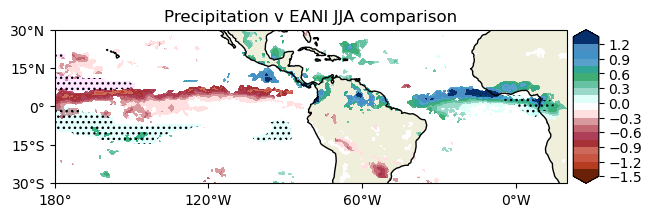

In [291]:
test = ens_jja_PRECTvEANI_sig_slope
cont = test * 1000 * (24*60*60)
tcomp = rEANI_JJAprecip_slope_sig

reg_map(cont, tcomp, 
        bounds=[20, -180, 30, -30], name='Precipitation v EANI JJA comparison',
        color=cmaps.precip4_diff_19lev)

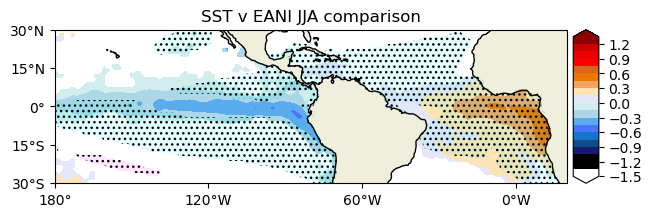

In [296]:
model = ens_jja_sstvEANI_sig_slope
reanalysis = rEANI_JJA_SST_slope_sig

reg_map(model, reanalysis, name='SST v EANI JJA comparison')

# Plots

## SST

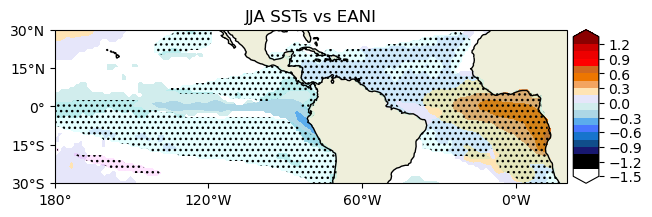

In [358]:
reg_map(ens_jja_sstvEANI_sig_slope, rEANI_JJA_SST_slope_sig,
        name='JJA SSTs vs EANI')

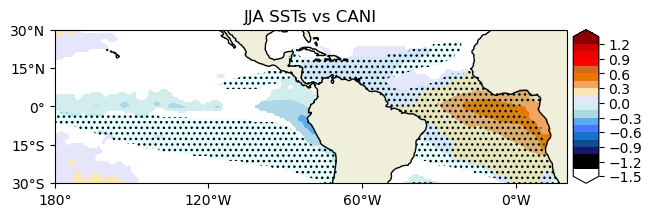

In [359]:
reg_map(ens_jja_sstvCANI_sig_slope, rCANI_JJA_SST_slope_sig,
        name='JJA SSTs vs CANI')

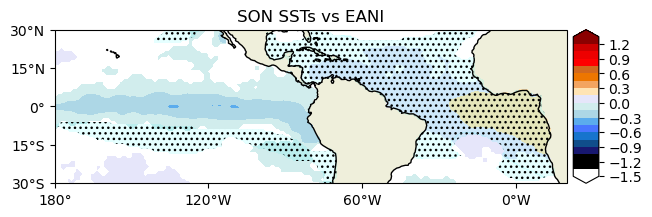

In [360]:
reg_map(ens_son_sstvEANI_sig_slope, rEANI_SON_SST_slope_sig, name='SON SSTs vs EANI')

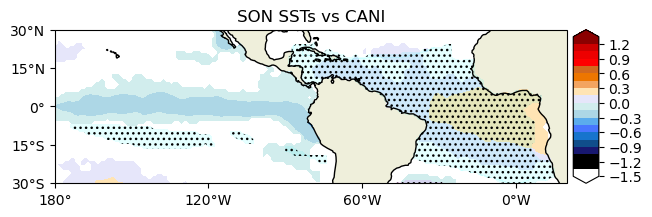

In [361]:
reg_map(ens_son_sstvCANI_sig_slope, rCANI_SON_SST_slope_sig, name='SON SSTs vs CANI')

## Precip

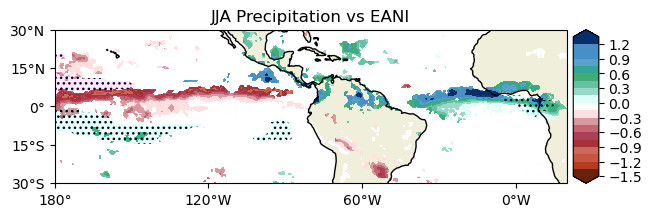

In [362]:
ens_jja_PRECTvEANI_con = ens_jja_PRECTvEANI_sig_slope * 1000 * (24*60*60)

reg_map(ens_jja_PRECTvEANI_con, rEANI_JJAprecip_slope_sig,
        name='JJA Precipitation vs EANI',
        color=cmaps.precip4_diff_19lev)

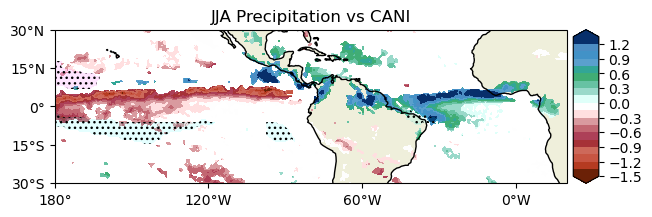

In [363]:
# conversion from m/s to mm/day
ens_jja_PRECTvCANI_con = ens_jja_PRECTvCANI_sig_slope * 1000 * (24*60*60)

reg_map(ens_jja_PRECTvCANI_con, rCANI_JJAprecip_slope_sig,
        name='JJA Precipitation vs CANI',
        color=cmaps.precip4_diff_19lev)

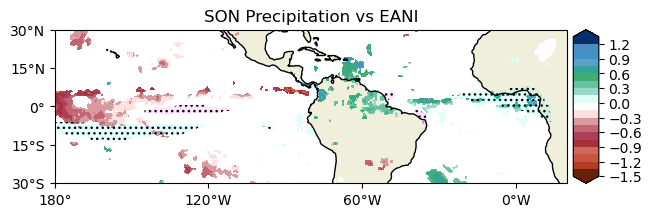

In [364]:
ens_son_PRECTvEANI_con = ens_son_PRECTvEANI_sig_slope * 1000 * (24 * 60 * 60)

reg_map(ens_son_PRECTvEANI_con, rEANI_SONprecip_slope_sig,
        name='SON Precipitation vs EANI',
        color=cmaps.precip4_diff_19lev)

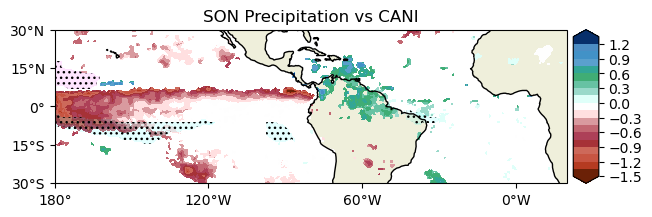

In [365]:
ens_son_PRECTvCANI_con = ens_jja_PRECTvCANI_sig_slope * 1000 * ( 24 * 60 * 60)

reg_map(ens_son_PRECTvCANI_con, rCANI_SONprecip_slope_sig,
        name='SON Precipitation vs CANI',
        color=cmaps.precip4_diff_19lev)